# Silhouette - Model Development Workflow (Mall Customers)

> **MLCourse · Machine Learning · unsupervised**

## What you'll learn
1. Combine elbow + mean-silhouette into ONE decision figure across k=2..10
2. Draw the full silhouette DIAGRAM for the chosen k=5 - sorted per-cluster
   bars, dashed cluster means, red global-mean line
3. Diagnose a deliberately BAD k (k=2) whose diagram shows negative tails
4. Extract practical guidance for choosing k in real projects

💡 This notebook is about JUDGING clusterings, not producing them - the model
is a plain K-Means; all intelligence goes into the evaluation.

In [1]:
# ---- Setup cell --------------------------------------------------------------------
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
import urllib.request


def get_data(fname: str, url: str) -> Path:
    """Course resolver: walk up to '02_machine_learning'; download once."""
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "02_machine_learning").is_dir():
            fpath = base / "02_machine_learning" / "data" / fname
            break
    else:
        raise RuntimeError("course data folder not found")
    if not fpath.exists():
        urllib.request.urlretrieve(url, fpath)
    return fpath

MALL_URL = ("https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/"
            "master/Machine%20Learning%20A-Z%20Template%20Folder/"
            "Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/"
            "Mall_Customers.csv")

## 1. Data + scaling (the boring-but-mandatory part)

In [2]:
mall = pd.read_csv(get_data("mall_customers.csv", MALL_URL))
feat_cols = ["Annual Income (k$)", "Spending Score (1-100)"]
scaler = StandardScaler()                          # identical coords for ALL trials
X = scaler.fit_transform(mall[feat_cols])          # silhouettes compare distances!
print(mall.shape, "customers ready for evaluation")

(200, 5) customers ready for evaluation


## 2. The combined k-selection figure (k = 2…10)

In [3]:
ks = range(2, 11)                                  # candidates under test
inertias, sils, label_bank = [], [], {}            # keep labels for later diagrams
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))   # fair: same X for every k
    label_bank[k] = km.labels_                     # stash for section 4/5

best_k = list(ks)[int(np.argmax(sils))]
print("silhouette by k:", dict(zip(ks, np.round(sils, 3))))

silhouette by k: {2: np.float64(0.321), 3: np.float64(0.467), 4: np.float64(0.494), 5: np.float64(0.555), 6: np.float64(0.54), 7: np.float64(0.528), 8: np.float64(0.455), 9: np.float64(0.457), 10: np.float64(0.443)}


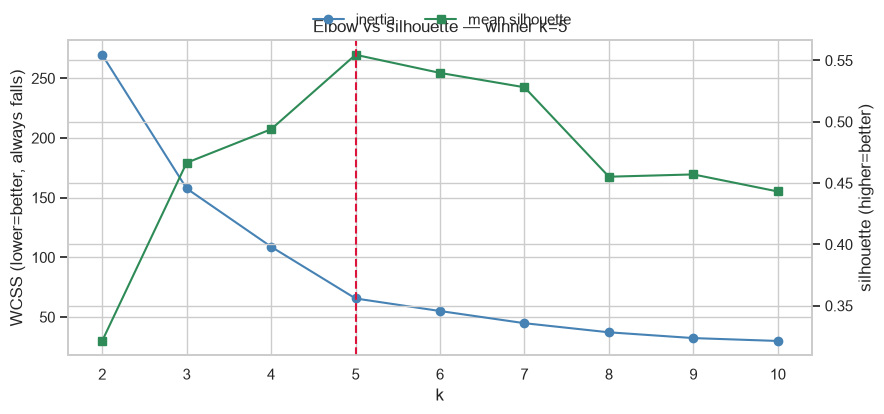

In [4]:
fig, ax1 = plt.subplots(figsize=(9, 4.2))          # twin axes: two judges, one look
ax1.plot(list(ks), inertias, marker="o", color="steelblue", label="inertia")
ax1.set_xlabel("k"); ax1.set_ylabel("WCSS (lower=better, always falls)")
ax2 = ax1.twinx()
ax2.plot(list(ks), sils, marker="s", color="seagreen", label="mean silhouette")
ax2.axvline(best_k, ls="--", color="crimson")      # silhouette's champion
ax2.set_ylabel("silhouette (higher=better)")
ax1.set_title(f"Elbow vs silhouette - winner k={best_k}")
fig.legend(loc="upper center", ncol=2, frameon=False)
plt.tight_layout(); plt.show()

⚠️ Inertia slides downhill forever; only the SILHOUETTE line is allowed to
crown a winner. Here it peaks at k=5 - matching the elbow's bend.

## 3. A reusable diagram builder

We will draw this diagnostic twice (good k and bad k), so we write ONE clean
function: sorted bars per cluster with gaps, dashed cluster means, red global
mean.

In [5]:
def silhouette_diagram(Xm, labels, ax, title):
    """Classic silhouette plot on a given axes - manual barh construction."""
    samples = silhouette_samples(Xm, labels)       # per-point scores
    pal = sns.color_palette("deep", len(np.unique(labels)))
    y_pos, tick_pos, tick_lab = 0, [], []
    for c, cl in enumerate(sorted(np.unique(labels))):
        vals = np.sort(samples[labels == cl])      # ascending within band
        start = y_pos
        for v in vals:                             # one barh per point
            ax.barh(y_pos, v, height=0.85,
                    color=pal[c], edgecolor="white", linewidth=0.3)
            y_pos += 1
        ax.plot([vals.mean()] * 2, [start - 0.8, y_pos - 0.2],
                ls="--", color=pal[c], lw=2)       # DASHED cluster-mean marker
        tick_pos.append((start + y_pos - 1) / 2)   # band centre -> ytick
        tick_lab.append(f"k{cl} (n={len(vals)})")
        y_pos += 6                                 # visual GAP between bands
    gmean = float(samples.mean())
    ax.axvline(gmean, color="red", lw=2,           # red GLOBAL mean line
               label=f"global mean {gmean:.3f}")
    neg = int((samples < 0).sum())                 # misassignment census
    ax.set_yticks(tick_pos); ax.set_yticklabels(tick_lab, fontsize=9)
    ax.set_xlabel("s(i)"); ax.set_title(title)
    ax.legend(loc="lower right")
    return gmean, neg                              # handy for narration

## 4. The GOOD case - full diagram at k=5

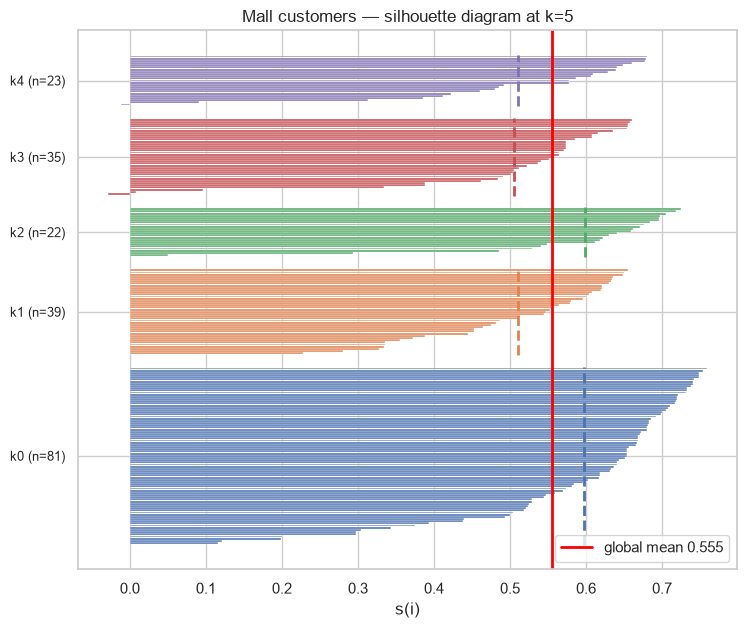

k=5: global mean 0.555, negative-s(i) points: 2


In [6]:
fig, ax = plt.subplots(figsize=(8.5, 7))
g5, neg5 = silhouette_diagram(X, label_bank[best_k], ax,
                              f"Mall customers - silhouette diagram at k={best_k}")
plt.show()
print(f"k={best_k}: global mean {g5:.3f}, negative-s(i) points: {neg5}")

Healthy signs at k=5: five thick-ish bands of comparable width, every dashed
cluster-mean near the red line, almost nobody left of zero. That is what an
actionable segmentation looks like ON PAPER.

## 5. The BAD case - same data, forced k=2

Two clusters must slice through the middle islands; their boundary residents
become closer to the OTHER side than home → long negative tails.

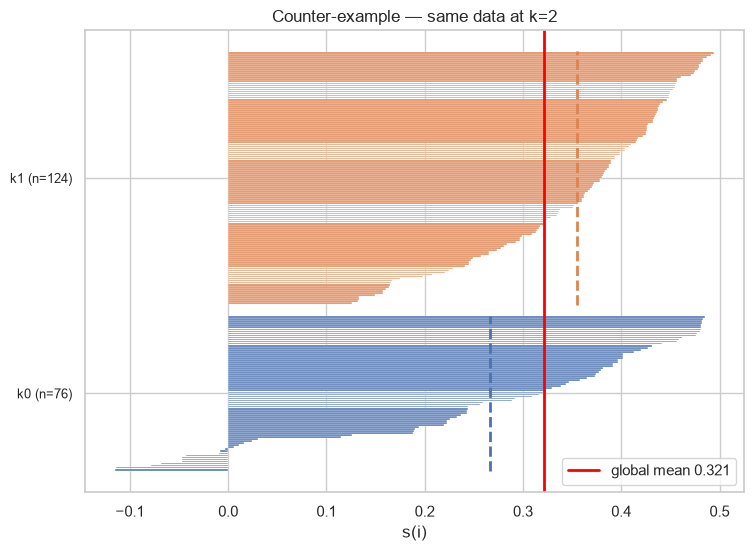

k=2: global mean 0.321, negative-s(i) points: 11


In [7]:
fig, ax = plt.subplots(figsize=(8.5, 6))
g2, neg2 = silhouette_diagram(X, label_bank[2], ax,
                              "Counter-example - same data at k=2")
plt.show()
print(f"k=2: global mean {g2:.3f}, negative-s(i) points: {neg2}")

Compare honestly: k=2 even has a HIGHER-or-equal mean than several larger k's
sometimes - but its diagram shows wide swaths of unhappy points squeezed
between two mega-blobs. 💡 **Read diagrams, not just means**: a number can't
show you negative tails; a picture can.

## Summary & guidance

- Decision recipe: scale once → sweep k with inertia+silhouette TOGETHER →
  shortlist top silhouette k's → inspect DIAGRAMS → pick with business sense.
- At k=5 the mall data shows balanced bands and ~no negatives - ship it.
  At k=2 negative tails betray boundary victims - reject despite simplicity.
- Practical thresholds for THIS course: prefer k where (a) mean s highest or
  near-highest, (b) no band is razor-thin, (c) negative count ≈ 0.
- ⚠️ Silhouette cost is O(n²): fine at n=200, sample before n≈100k.